# Week path search editor

Editor/building playground (somethingsomething) for a function that takes a file apth with week ifnromation and finds other weeks for that file.

Replaces the part of the path with "W{number}" by another number in the string.

In [1]:
import re
from pathlib import Path

When we call this searching function in our avg_vol module, as input for weeks, do p_weeks or just all possible weeks and this will determine if all weeks exist?

In [44]:
def week_path_search(reference_file, weeks = [0, 4, 12, 24, 52]):
    """
    Inputs:
        reference_file (str): path to a file whose path will be used as reference.
            That is, this file's path should have the structure that all other files from that week should have.
        weeks: weeks in filepath
    
    Outputs:
        week_paths (list[str]): paths to all files (including reference) that exist for weeks
        week_available (list[str]): weeks whose files exist
    """

    ref_path = str(reference_file)

    # find all places in path with the week
    match = re.search(r'W(\d+)', ref_path)
    if not match:
        print(f'could not find week token in reference path for {ref_path}')
        return None
    
    ref_week_token = match.group(1) # return entire text that ws matched.

    weeks_paths = []
    weeks_available = []

    for week in weeks:
        # search for every week's file

        # replace the week token(s) in reference image path with other tokens for new week path
        #week_path = ref_path.replace(ref_week_token, f'W{week}')

        week_path = re.sub(rf'W{ref_week_token}(?!\d)', f'W{week}', ref_path)

        if not Path(week_path).exists():
            print(f'skipping W{week}')
            continue

        weeks_paths.append(week_path)
        weeks_available.append(week) # add weeks as integers

    return weeks_paths, weeks_available

In [45]:
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'


In [46]:
subj_id = 'UZ_2565'
refT1 = 'W0'
ref_img = f'{base_dir}/MNISym_GM/{subj_id}/{subj_id}_{refT1}_MNISym_GM_reslice.nii.gz'
#ref_img = f'{base_dir}/anatomicals/{subj_id}/{refT1}/{subj_id}_{refT1}_T1.nii'

In [47]:
paths, avail = week_path_search(ref_img)

skipping W4
skipping W12
skipping W52


In [48]:
paths

['/cifs/diedrichsen/data/smarts_cerebellum/MNISym_GM/UZ_2565/UZ_2565_W0_MNISym_GM_reslice.nii.gz',
 '/cifs/diedrichsen/data/smarts_cerebellum/MNISym_GM/UZ_2565/UZ_2565_W24_MNISym_GM_reslice.nii.gz']

In [49]:
avail

[0, 24]

## Now let's use our new function to modularize `avg_vol`

### Starting with sufficient_weeks loop

In [50]:
def sufficient_weeks(reference_img):

    # need at least 2 measurement weeks to run our regression, to determine how many weeks there are

    # this function will search for all week files, such that week files are the same path structure as the reference file, but exist for other weeks
    p_paths, p_weeks = week_path_search(reference_img)
    
    if len(p_weeks) == 1: # only one measurement week available
        return None # exit function (skip subject)    
    
    return p_weeks, p_paths

When you call sufficient_weeks, call it like `p_weeks, p_paths = sufficient_weeks(reference_img)`

### Now on our response_matrix loop

In [ ]:
def response_matrix(Y, 
                    x, y, z, 
                    tissue,
                    p_weeks, p_paths
                    ):
    
  

    for row_idx, week_path in enumerate(p_paths): # enumerate through actual week and store the index of that week
        # so (e.g.) if W0, W24, then store their flattened arrays in rows 1 and 2 respectively in Y matrix
        
        # we've already returned all the week paths (images) that are available for a given subject, so just use those

        print(f'{week_path} is in Y index {row_idx}')

        week_img = nib.load(week_path)

        
        Y[row_idx, :] = nt.sample_image(week_img, 
                                        xm=x, ym=y, zm=z,
                                        interpolation=1 # trilinear interpolation (since 3 dimensions in array)
                                        ).flatten() # store each (resampled) voxel array as a row vector for each week
    return Y 

### put this in the full function

In [25]:
# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl
from nilearn import masking # for masking within-brain voxels

import nitools as nt

import os

In [51]:
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'

In [53]:
# need to rename this and fix comment documentation.

"""
Calculates average image for a subject over all time points. For example, get the average white matter image for a subject.

Uses a multiple linear regression model.
"""

# Imports



# helper functions

def sufficient_weeks(reference_img):

    # need at least 2 measurement weeks to run our regression, to determine how many weeks there are

    # this function will search for all week files, such that week files are the same path structure as the reference file, but exist for other weeks
    p_paths, p_weeks = week_path_search(reference_img)
    
    if len(p_weeks) == 1: # only one measurement week available
        return None # exit function (skip subject)    
    
    return p_weeks, p_paths


# this entire loop could probably be its own fucntion.
def response_matrix(Y, 
                    x, y, z, 
                    tissue,
                    p_weeks, p_paths
                    ):
    
  

    for row_idx, week_path in enumerate(p_paths): # enumerate through actual week and store the index of that week
        # so (e.g.) if W0, W24, then store their flattened arrays in rows 1 and 2 respectively in Y matrix
        
        # we've already returned all the week paths (images) that are available for a given subject, so just use those

        print(f'{week_path} is in Y index {row_idx}')

        week_img = nib.load(week_path)

        
        Y[row_idx, :] = nt.sample_image(week_img, 
                                        xm=x, ym=y, zm=z,
                                        interpolation=1 # trilinear interpolation (since 3 dimensions in array)
                                        ).flatten() # store each (resampled) voxel array as a row vector for each week
    return Y 

# add input: type of file (e.g. native, tissue_resliced, etc.)
def avg_vol(subj_id, 
            reference_img, # reference anatomical
            #week_path, # path to week image
            results_path,
            image_suffix,
            subpath = None, # specify subfolder
            input_suffix = None, # suffix for input image; MUST begin with '_'
            tissue=None):
    """
    Inputs:
    updated again
    anat dir: participants file OR [(subj, week) and call it inside a loop].
    Reference img (inside the Jupyter notebook loop for reading off the info file)
    #week_path (path for each week's image), results_path (store results)
    results path: directory to store results
    subpath: path with the images, usually same as the reference image's parent folder
    image suffix: suffix with which to save the slope and intercept images
        suggested: <image_type>_<space> where 'image_type' is "anat", "wm", "gm", etc; 'space' is native or template (<template_name>)
    input_suffix: suffix for input image, if applicable (default = None) - if supplying, must being with "_"

    Everything is done in the reference image. So this function will (...) (resample voxels in other weeks so that they are aligned with the reference, and perform multiple linear regression)

    Returns B_hat coefficient matrix (for more flexibility in other possible operations)
    
    """

    
    img0 = nib.load(reference_img)

    # later fix: option to reduce to only wtihin-brain voxels
    
    # transform into world coordinates
    i, j, k = np.indices(img0.shape) # matrix indices for premult by affine
    x,y,z = nt.affine_transform(i, j, k, img0.affine)

    
    p_weeks, p_paths = sufficient_weeks(reference_img)


    Y_empty = np.zeros((len(p_weeks), np.prod(img0.shape))) # initialize Y (shape = (k by p)) array, where k = number of weeks available

    Y = response_matrix(Y_empty,
                        x,y,z,
                        tissue,
                        p_weeks, p_paths)
    
    # design matrix
    num_weeks = len(p_weeks)
    X = [np.ones(shape = (num_weeks)), p_weeks] # p_weeks must be INTEGER (or some type of number, like float) for matrix
    X = np.array(X)
    X = X.T

    # estimator (coefficients matrix)
    B_hat = np.linalg.pinv(X) @ Y
    # where B_hat = [B_0 B_1].T

    #_________________
    # save image with voxel coordinates
    slope = np.zeros(img0.shape) # tensor with shape of reference img
    intercept = np.zeros(img0.shape)
    # need i, j, k as vectors (they're tensors right now)

    iv = i.flatten()
    jv = j.flatten()
    kv = k.flatten()

    slope[iv, jv, kv] = B_hat[1,:] # write the slope into the vectors i, j, k for coordinates
    intercept[iv, jv, kv] = B_hat[0,:]
    #________________

    """
    Joern's pseudocode

    results = np.zeros(img0.shape)
    results(i,j,k)=B(:,1) # Slopw
    nifti = np.Nifti1image(results,img0.affine)
    niftt.to_filename()

    """

    # intercept and slope reshaped into Nifti-compatible array
    #intercept = B_hat[0,:].reshape(img0.shape)
    #slope = B_hat[1,:].reshape(img0.shape)

    """
    So this image is in world coordinates now, and saved with the affine of the original image.
    Should it be converted back to voxel coordinates (bc otherwise, the affine is kinda meaningless)?

    # intercept and slope are already world-coordinates array, so multiply by inverse affine
    
    """
    
    # save as Nifti
    intercept_img = nib.Nifti1Image(intercept, img0.affine)
    slope_img = nib.Nifti1Image(slope, img0.affine)

    #nib.save(intercept_img, f'{results_path}/{subj_id}_intercept_{image_suffix}.nii.gz') # specify file name
    #nib.save(slope_img, f'{results_path}/{subj_id}_slope_{image_suffix}.nii.gz')

    return B_hat, X, Y, intercept_img, slope_img

In [62]:
p_df = pd.read_csv(f'{base_dir}/participants_anat.tsv', sep = '\t')

In [63]:
p_df = p_df[p_df.subj_id == 'UZ_2565']

In [31]:
avg_vol?

Signature:
avg_vol(
    subj_id,
    reference_img,
    results_path,
    image_suffix,
    subpath=None,
    input_suffix=None,
    tissue=None,
)
Docstring:
Inputs:
updated again
anat dir: participants file OR [(subj, week) and call it inside a loop].
Reference img (inside the Jupyter notebook loop for reading off the info file)
#week_path (path for each week's image), results_path (store results)
results path: directory to store results
subpath: path with the images, usually same as the reference image's parent folder
image suffix: suffix with which to save the slope and intercept images
    suggested: <image_type>_<space> where 'image_type' is "anat", "wm", "gm", etc; 'space' is native or template (<template_name>)
input_suffix: suffix for input image, if applicable (default = None) - if supplying, must being with "_"

Everything is done in the reference image. So this function will (...) (resample voxels in other weeks so that they are aligned with the reference, and perform multi

In [64]:
p_df

,SN,ID,Centre,Week,week,RefT1,numrun,nslices,Hand,LesionSide,...,surfmvpa,include1,lesiondef,behavior_missing,behavior_blocks,has_mvc,DTImap_missing,CentreNo,machine,subj_id
69,70,2565,UZ,W0,0,W0,5,35,b,right,...,1,1,1,0,5,1,0,3,naveed,UZ_2565
70,71,2565,UZ,W24,24,W0,4,35,b,right,...,1,1,1,0,4,1,0,3,naveed,UZ_2565


In [65]:
# CALL FOR WM SEGMENTATION IMAGE IN NATIVE SPACE________


for subj in p_df['subj_id'].unique():
    #betas.append(avg_vol(subj, ref_img))
    refT1 = (p_df.loc[(p_df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    ref_img = f'{anat_dir}/{subj}/{refT1}/c2{subj}_{refT1}_T1.nii'

    betas, X, Y, intercept_img, slope_img = avg_vol(subj_id = subj_id,
                         reference_img = ref_img,
                         results_path = 'trial_folder_del',
                         image_suffix = 'trial_del',
                         tissue = 'wm'

                         )
     
    # we don't need this weeks loop, the function does it. Really just need to loop through the subject and get their reference img
    # even better if the function can get the reference image itself.
    
    #week = p_df.loc[(p_df['subj_id']==subj), 'week'].iloc[1]
   



skipping W4
skipping W12
skipping W52
/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/UZ_2565/W0/c2UZ_2565_W0_T1.nii is in Y index 0
/cifs/diedrichsen/data/smarts_cerebellum/anatomicals/UZ_2565/W24/c2UZ_2565_W24_T1.nii is in Y index 1


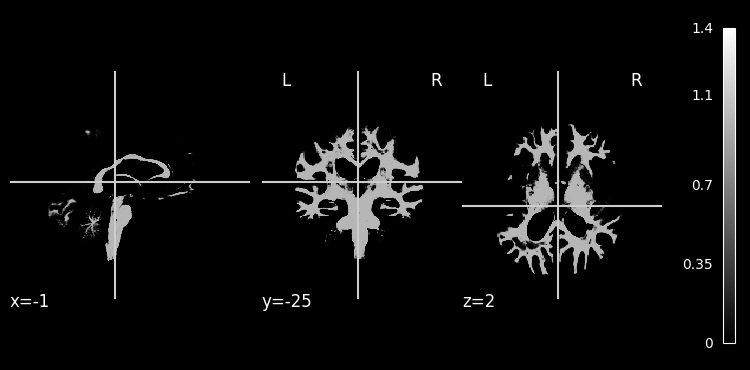

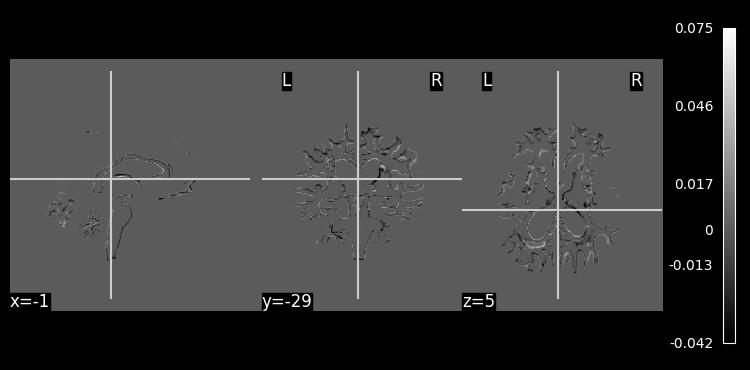

In [66]:
npl.plot_anat(intercept_img)
npl.plot_anat(slope_img)

## need to clean up inside of the main `avg_vol` function, including its calls, before being done.